In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
import requests

def get_sp500_tickers():
    """
    Scrape S&P 500 constituents from Wikipedia.
    Returns a list of ticker symbols.
    """
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    
    # simulate a browser to avoid error 403
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    
    response = requests.get(url, headers=headers)
    table = pd.read_html(response.text)[0]
    tickers = table['Symbol'].tolist()
    
    # Yahoo Finance uses '-' instead of '.' (es. BRK.B → BRK-B)
    tickers = [t.replace('.', '-') for t in tickers]
    
    print(f"Tickers found: {len(tickers)}")
    return tickers, table

tickers, sp500_table = get_sp500_tickers()
sp500_table[['Symbol', 'Security', 'GICS Sector']].head(10)

Tickers found: 503


,Symbol,Security,GICS Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology
5,ADBE,Adobe Inc.,Information Technology
6,AMD,Advanced Micro Devices,Information Technology
7,AES,AES Corporation,Utilities
8,AFL,Aflac,Financials
9,A,Agilent Technologies,Health Care


In [8]:
def download_prices(tickers, start="2010-01-01", end="2024-12-31"):
    """
    Download adjusted closing prices for all tickers.
    Uses yfinance batch download for efficiency.
    """
    print(f"Downloading prices for {len(tickers)} tickers...")
    
    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,   # prices are already adjusted
        progress=True
    )
    
    # Teniamo solo il Close price
    prices = raw['Close']
    
    print(f"\nShape: {prices.shape}")
    print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
    print(f"Tickers downloaded: {prices.shape[1]}")
    
    return prices

prices = download_prices(tickers)

[**********************47%                       ]  237 of 503 completed$Q: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1735621200")
[**********************74%***********            ]  370 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1735621200")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1735621200")



Shape: (3773, 503)
Date range: 2010-01-04 → 2024-12-30
Tickers downloaded: 503


=== Data Quality Report ===
Total tickers: 503
Complete tickers (0% missing): 423
Tickers with >50% missing data: 27

Missing data distribution:
count    503.00
mean       6.32
std       18.43
min        0.00
25%        0.00
50%        0.00
75%        0.00
max      100.00
dtype: float64


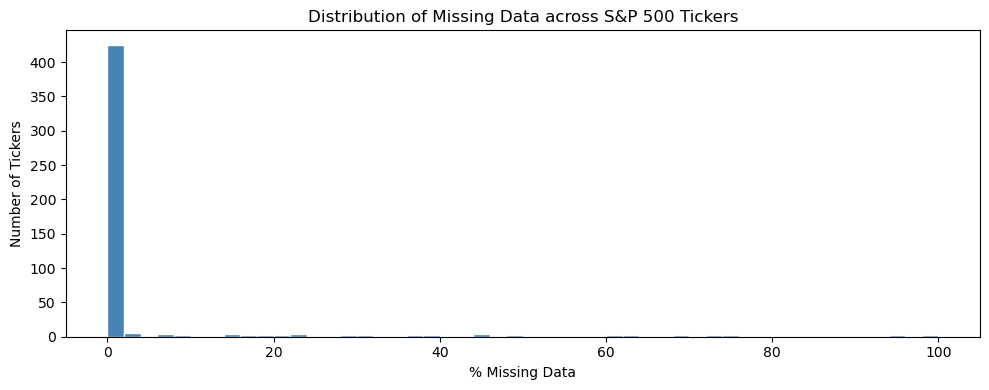

In [10]:
# How many data is missing?
missing_pct = prices.isnull().mean() * 100

print("=== Data Quality Report ===")
print(f"Total tickers: {prices.shape[1]}")
print(f"Complete tickers (0% missing): {(missing_pct == 0).sum()}")
print(f"Tickers with >50% missing data: {(missing_pct > 50).sum()}")
print(f"\nMissing data distribution:")
print(missing_pct.describe().round(2))

# Visualize the distribution of the missing data
plt.figure(figsize=(10, 4))
plt.hist(missing_pct, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('% Missing Data')
plt.ylabel('Number of Tickers')
plt.title('Distribution of Missing Data across S&P 500 Tickers')
plt.tight_layout()
plt.show()

In [12]:
# 1. Calculate daily returns
returns = prices.pct_change()

# 2. Identify extreme returns (>100% or <-50% in a single day)
extreme_returns = (returns.abs() > 1.0)
tickers_with_spikes = extreme_returns.any()
print(f"Tickers with extreme returns (>100% in one day): {tickers_with_spikes.sum()}")
print(tickers_with_spikes[tickers_with_spikes].index.tolist())

# 3. Check for zero or negative prices
zero_prices = (prices <= 0).any()
print(f"\nTickers with zero or negative prices: {zero_prices.sum()}")

# 4. Check the length of available history for each ticker
history_length = prices.notna().sum()
short_history = history_length[history_length < 252]  # less than 1 year of data
print(f"\nTickers with less than 1 year of history: {len(short_history)}")
print(short_history.sort_values())

Tickers with extreme returns (>100% in one day): 0
[]

Tickers with zero or negative prices: 0

Tickers with less than 1 year of history: 4
Ticker
Q         0
SNDK      0
GEV     192
SOLV    193
dtype: int64


In [14]:
def clean_prices(prices, max_missing_pct=20, min_history_days=252):
    """
    Remove tickers with:
    - Too much missing data
    - Insufficient price history (less than 1 year)
    """
    # Remove tickers with too much missing data
    missing_pct = prices.isnull().mean() * 100
    valid_by_missing = missing_pct[missing_pct <= max_missing_pct].index

    # Remove tickers with insufficient history
    history_length = prices.notna().sum()
    valid_by_history = history_length[history_length >= min_history_days].index

    # Intersection: tickers valid for both criteria
    valid_tickers = valid_by_missing.intersection(valid_by_history)
    prices_clean = prices[valid_tickers].copy()

    print(f"Tickers before cleaning:         {prices.shape[1]}")
    print(f"Removed due to missing data:     {prices.shape[1] - len(valid_by_missing)}")
    print(f"Removed due to short history:    {prices.shape[1] - len(valid_by_history)}")
    print(f"Tickers after cleaning:          {prices_clean.shape[1]}")
    
    return prices_clean

prices_clean = clean_prices(prices)

# Save locally
prices_clean.to_parquet('../data/sp500_prices.parquet')
print("\nData saved to data/sp500_prices.parquet")

Tickers before cleaning:         503
Removed due to missing data:     54
Removed due to short history:    4
Tickers after cleaning:          449

Data saved to data/sp500_prices.parquet


**METHODOLOGICAL NOTE** 

Dataset: S&P 500 constituents (source: Wikipedia, updated to present)
Period: 2010-01-01 / 2024-12-31
Final tickers: see output of cell 6

KNOWN LIMITATIONS:

1. SURVIVORSHIP BIAS
   The ticker list is based on the current composition of the S&P 500.
   Companies removed from the index or that went bankrupt between 2010 and 2024 are not included.
   This introduces an upward bias in backtest returns.
   Professional datasets (CRSP, Compustat) address this issue
   but are not freely available.

2. LOOKAHEAD BIAS
   This will be handled in signal construction (notebook 02):
   momentum at each time t will only use prices available up to t.

These limitations will be documented in the final research memo.

In [16]:
# 1. Dataset shape
print("=== DATASET STRUCTURE ===")
print(f"Rows (trading days): {prices_clean.shape[0]}")
print(f"Columns (tickers):   {prices_clean.shape[1]}")

# 2. Preview of the dataframe
print("\n=== FIRST 5 ROWS, FIRST 6 TICKERS ===")
print(prices_clean.iloc[:5, :6].round(2))

# 3. Time index information
print("\n=== TIME INDEX ===")
print(f"Index type:  {type(prices_clean.index)}")
print(f"Start date:  {prices_clean.index[0].date()}")
print(f"End date:    {prices_clean.index[-1].date()}")
print(f"Frequency:   trading days (no weekends, no holidays)")

# 4. Example ticker
print("\n=== EXAMPLE: APPLE (AAPL) ===")
print(prices_clean['AAPL'].dropna().head(10).round(2))

# 5. Descriptive statistics for a sample
print("\n=== DESCRIPTIVE STATISTICS (first 5 tickers) ===")
print(prices_clean.iloc[:, :5].describe().round(2))

=== DATASET STRUCTURE ===
Rows (trading days): 3773
Columns (tickers):   449

=== FIRST 5 ROWS, FIRST 6 TICKERS ===
Ticker          A  AAPL  ABBV    ABT  ACGL    ACN
Date                                             
2010-01-04  19.81  6.41   NaN  18.21  7.60  31.23
2010-01-05  19.60  6.42   NaN  18.06  7.58  31.42
2010-01-06  19.53  6.32   NaN  18.16  7.54  31.75
2010-01-07  19.50  6.31   NaN  18.31  7.50  31.72
2010-01-08  19.49  6.35   NaN  18.41  7.48  31.60

=== TIME INDEX ===
Index type:  <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Start date:  2010-01-04
End date:    2024-12-30
Frequency:   trading days (no weekends, no holidays)

=== EXAMPLE: APPLE (AAPL) ===
Date
2010-01-04    6.41
2010-01-05    6.42
2010-01-06    6.32
2010-01-07    6.31
2010-01-08    6.35
2010-01-11    6.30
2010-01-12    6.22
2010-01-13    6.31
2010-01-14    6.28
2010-01-15    6.17
Name: AAPL, dtype: float64

=== DESCRIPTIVE STATISTICS (first 5 tickers) ===
Ticker        A     AAPL     ABBV      ABT 